In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from scipy.spatial.distance import cityblock, euclidean
import regex as re
from wordcloud import WordCloud

# COMPARE SBERT AND BERT WITH MEAN POOLING WITH CUSTOM DATASET

In [2]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class BERTSentenceTransformer(nn.Module):
    def __init__(self, model_name="bert-base-uncased"):
        super(BERTSentenceTransformer, self).__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)
    
    def mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        
        return sum_embeddings / sum_mask
    
    def forward(self, sentences):
        encoded_input = self.tokenizer(
            sentences, padding=True, truncation=True, return_tensors='pt'
        )
        
        with torch.no_grad():
            model_output = self.bert(**encoded_input)
        
        sentence_embeddings = self.mean_pooling(model_output, encoded_input['attention_mask'])
        return sentence_embeddings
    
customModel = BERTSentenceTransformer()
customModel

BERTSentenceTransformer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [3]:
model = SentenceTransformer("sentence-transformers/all-distilroberta-v1")
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False}) with Transformer model: RobertaModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [4]:
def compute_scores(model, reference_answer, student_answer):
    ref_embedding = model.encode(reference_answer, normalize_embeddings=True)
    student_embedding = model.encode(student_answer, normalize_embeddings=True)

    cos_sim = util.cos_sim(ref_embedding, student_embedding).item()
    manhattan_dist = cityblock(ref_embedding, student_embedding)
    euclidean_dist = euclidean(ref_embedding, student_embedding)

    return cos_sim, manhattan_dist, euclidean_dist

print("pair 1 : ", {compute_scores(model, "She is reading a novel in the library.", "She is studying a textbook in the library.")})
print("pair 2 : ", {compute_scores(model, "They are playing football at the park.", "They are playing basketball at the park.")})
print("pair 3 : ", {compute_scores(model, "I will visit my grandmother this weekend.", "I plan to see my grandfather this weekend.")})
print("pair 4 : ", {compute_scores(model, "He is cooking dinner for his family.", "He is preparing lunch for his family.")})
print("pair 5 : ", {compute_scores(model, "The dog is barking loudly at night.", "The dog is howling loudly at night.")})
print("pair 6 : ", {compute_scores(model, "She is reading a novel in the library.", "The sun is shining brightly in the sky.")})
print("pair 7 : ", {compute_scores(model, "They are playing football at the park.", "She is baking a cake in the kitchen.")})
print("pair 8 : ", {compute_scores(model, "I will visit my grandmother this weekend.", "The company announced a new product today.")})
print("pair 9 : ", {compute_scores(model, "He is cooking dinner for his family.", "I bought a new phone yesterday.")})
print("pair 10 : ", {compute_scores(model, "The dog is barking loudly at night.", "She is painting a beautiful landscape.")})

print("pair : ", {compute_scores(model, "She is reading a novel in the library. Anton come to her to give the book she ask. She is waiting in the library for Anton to come.", 
                                 "The library is the place where she was reading a novel. Anton going to library because She is waiting there. She ask Anton to come and give the book she ask")})


c:\Users\User\Documents\Code\env\lib\site-packages\transformers\models\roberta\modeling_roberta.py:370: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


pair 1 :  {(0.806517481803894, 13.614122, 0.6220654249191284)}
pair 2 :  {(0.5862067341804504, 19.779488, 0.909717857837677)}
pair 3 :  {(0.8051597476005554, 13.707868, 0.6242437958717346)}
pair 4 :  {(0.7270820140838623, 15.670829, 0.7388072609901428)}
pair 5 :  {(0.80778968334198, 13.373181, 0.6200167536735535)}
pair 6 :  {(0.038037415593862534, 30.559011, 1.3870563507080078)}
pair 7 :  {(-0.06773745268583298, 32.190536, 1.4613264799118042)}
pair 8 :  {(0.05526435002684593, 30.097795, 1.3745805025100708)}
pair 9 :  {(0.029967647045850754, 30.236008, 1.39286208152771)}
pair 10 :  {(-0.04524291679263115, 31.448261, 1.44585120677948)}
pair :  {(0.8349795341491699, 12.3578205, 0.5744921565055847)}


In [5]:
def compute_scores(model, reference_answer, student_answer):
    # Dapatkan embeddings dari model
    ref_embedding = model([reference_answer])
    student_embedding = model([student_answer])

    # Normalisasi embeddings
    ref_embedding = nn.functional.normalize(ref_embedding, p=2, dim=1)
    student_embedding = nn.functional.normalize(student_embedding, p=2, dim=1)

    # Hitung Cosine Similarity
    cos_sim = torch.nn.functional.cosine_similarity(ref_embedding, student_embedding).item()

    # Ubah embeddings menjadi numpy array untuk menghitung jarak
    ref_np = ref_embedding.cpu().numpy()[0]
    student_np = student_embedding.cpu().numpy()[0]

    # Hitung jarak Manhattan dan Euclidean
    manhattan_dist = cityblock(ref_np, student_np)
    euclidean_dist = euclidean(ref_np, student_np)

    return cos_sim, manhattan_dist, euclidean_dist

print("pair 1 : ", {compute_scores(customModel, "She is reading a novel in the library.", "She is studying a textbook in the library.")})
print("pair 2 : ", {compute_scores(customModel, "They are playing football at the park.", "They are playing basketball at the park.")})
print("pair 3 : ", {compute_scores(customModel, "I will visit my grandmother this weekend.", "I plan to see my grandfather this weekend.")})
print("pair 4 : ", {compute_scores(customModel, "He is cooking dinner for his family.", "He is preparing lunch for his family.")})
print("pair 5 : ", {compute_scores(customModel, "The dog is barking loudly at night.", "The dog is howling loudly at night.")})
print("pair 6 : ", {compute_scores(customModel, "She is reading a novel in the library.", "The sun is shining brightly in the sky.")})
print("pair 7 : ", {compute_scores(customModel, "They are playing football at the park.", "She is baking a cake in the kitchen.")})
print("pair 8 : ", {compute_scores(customModel, "I will visit my grandmother this weekend.", "The company announced a new product today.")})
print("pair 9 : ", {compute_scores(customModel, "He is cooking dinner for his family.", "I bought a new phone yesterday.")})
print("pair 10 : ", {compute_scores(customModel, "The dog is barking loudly at night.", "She is painting a beautiful landscape.")})

print("pair : ", {compute_scores(customModel, "She is reading a novel in the library. Anton come to her to give the book she ask. She is waiting in the library for Anton to come.", 
                                 "The library is the place where she was reading a novel. Anton going to library because She is waiting there. She ask Anton to come and give the book she ask")})

pair 1 :  {(0.9586226940155029, 6.4019, 0.2876713275909424)}
pair 2 :  {(0.885614275932312, 10.525023, 0.47830063104629517)}
pair 3 :  {(0.8980713486671448, 9.98587, 0.4515056312084198)}
pair 4 :  {(0.9530850648880005, 6.7154703, 0.30631670355796814)}
pair 5 :  {(0.9803255200386047, 4.385399, 0.19836585223674774)}
pair 6 :  {(0.7380141019821167, 15.90271, 0.7238591909408569)}
pair 7 :  {(0.6104083061218262, 19.136974, 0.8827137351036072)}
pair 8 :  {(0.5356910824775696, 21.362736, 0.96364825963974)}
pair 9 :  {(0.6311719417572021, 18.786957, 0.858869194984436)}
pair 10 :  {(0.6855636239051819, 17.417198, 0.7930150032043457)}
pair :  {(0.9403259754180908, 7.5440607, 0.345468133687973)}


# COMPARE SBERT USING DATASET

In [6]:
df = pd.read_csv("../../data/aes_dataset.csv")
df = df[['reference_answer', 'answer', 'score', 'dataset', 'normalized_score']]
print(df.info())
print(df['dataset'].value_counts())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22406 entries, 0 to 22405
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  22406 non-null  object 
 1   answer            22406 non-null  object 
 2   score             22406 non-null  float64
 3   dataset           22406 non-null  object 
 4   normalized_score  22406 non-null  float64
dtypes: float64(2), object(3)
memory usage: 875.4+ KB
None
dataset
asap              17043
sag                2558
analisis_essay     2162
stita               333
cunlp               171
sci                 139
Name: count, dtype: int64


,reference_answer,answer,score,dataset,normalized_score
0,Fungsi karbohidrat adalah sebagai pemasok ener...,"sumber tenaga, pemanis alami, menjaga sistem i...",27.0,analisis_essay,0.27
1,Fungsi karbohidrat adalah sebagai pemasok ener...,"sebagai sumber energi, pemanis alami, menjaga ...",21.0,analisis_essay,0.21
2,Fungsi karbohidrat adalah sebagai pemasok ener...,1. Sebagai energi. 2. Sebagai memperlancaar pe...,42.0,analisis_essay,0.42
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"untuk membuat kenyang, agar tidak lapar, agar ...",18.0,analisis_essay,0.18
4,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat mempunyai peran penting untuk pros...,82.0,analisis_essay,0.82


In [7]:
models = {
    "distilroberta": "sentence-transformers/all-distilroberta-v1",
    "minilm": "sentence-transformers/all-MiniLM-L6-v2"
}
datasets = ["sag", "stita", "sci", "cunlp", "asap"]

In [8]:
def preprocess_text(text):
    """Add text preprocessing steps"""
    # Remove extra whitespace
    text = ' '.join(text.split())
    # Convert to lowercase
    text = text.lower()
    # Remove special characters (keep punctuation)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    return text

In [9]:
def compute_scores(model, reference_answer, student_answer):
    # Preprocess text
    reference_answer = preprocess_text(reference_answer)
    student_answer = preprocess_text(student_answer)
    
    ref_embedding = model.encode(reference_answer, normalize_embeddings=True)
    student_embedding = model.encode(student_answer, normalize_embeddings=True)

    cos_sim = util.cos_sim(ref_embedding, student_embedding).item()
    manhattan_dist = cityblock(ref_embedding, student_embedding)
    euclidean_dist = euclidean(ref_embedding, student_embedding)

    return cos_sim, manhattan_dist, euclidean_dist

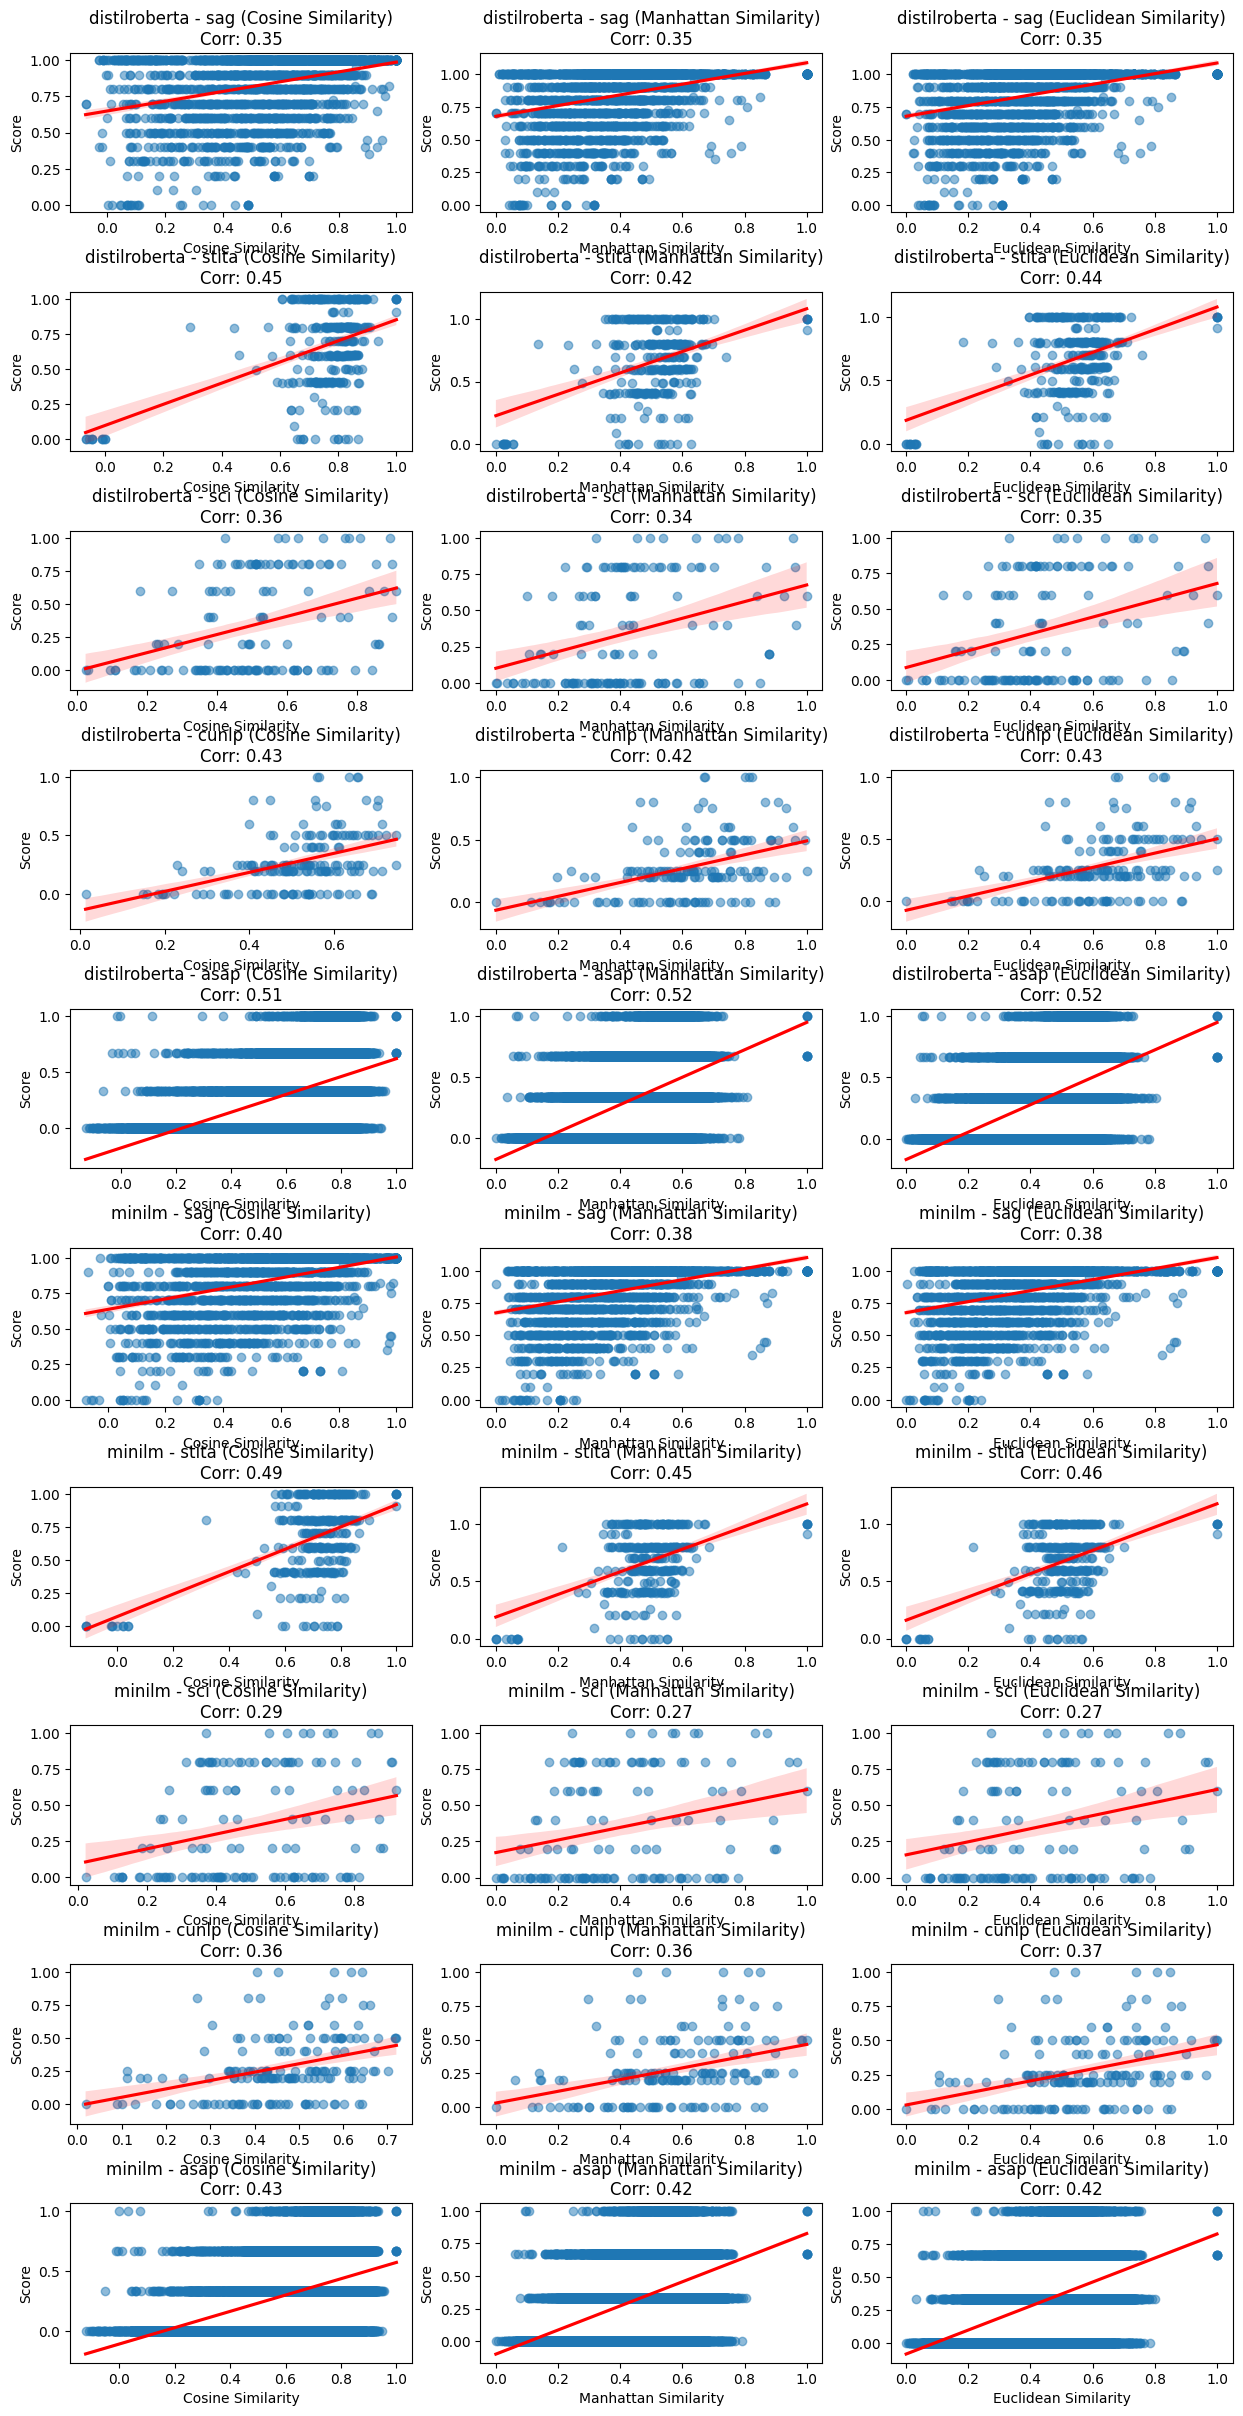

In [ ]:
fig, axes = plt.subplots(10, 3, figsize=(15, 30)) 
plt.subplots_adjust(hspace=0.5)

plot_idx = 0  # Untuk tracking subplot index
# Loop untuk semua kombinasi model dan dataset
for model_name, model_path in models.items():
    model = SentenceTransformer(model_path)  # Load model sekali per iterasi

    for dataset in datasets:
        df_subset = df[df["dataset"] == dataset].copy()

        # Hitung skor
        scores = df_subset.apply(
            lambda x: compute_scores(model, x["reference_answer"], x["answer"]), axis=1
        )
        df_subset["cos_sim"], df_subset["manhattan_dist"], df_subset["euclidean_dist"] = zip(*scores)
        # Normalize distances to convert them into similarity scores
        df_subset["manhattan_sim"] = 1 - (df_subset["manhattan_dist"] - df_subset["manhattan_dist"].min()) / (df_subset["manhattan_dist"].max() - df_subset["manhattan_dist"].min())
        df_subset["euclidean_sim"] = 1 - (df_subset["euclidean_dist"] - df_subset["euclidean_dist"].min()) / (df_subset["euclidean_dist"].max() - df_subset["euclidean_dist"].min())


        # Hitung korelasi
        cos_corr = df_subset["cos_sim"].corr(df_subset["normalized_score"])
        # Calculate correlations after transforming distances to similarity
        man_corr = df_subset["manhattan_sim"].corr(df_subset["normalized_score"])
        euc_corr = df_subset["euclidean_sim"].corr(df_subset["normalized_score"])


        # Plot untuk masing-masing skor
        for i, (score_type, score_col, correlation) in enumerate(
            [("Cosine Similarity", "cos_sim", cos_corr),
            ("Manhattan Similarity", "manhattan_sim", man_corr),
            ("Euclidean Similarity", "euclidean_sim", euc_corr)]
        ):

            ax = axes[plot_idx, i]
            sns.regplot(x=df_subset[score_col], y=df_subset["normalized_score"],
                        scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax)

            ax.set_xlabel(score_type)
            ax.set_ylabel("Score")
            ax.set_title(f"{model_name} - {dataset} ({score_type})\nCorr: {correlation:.2f}")

        plot_idx += 1  # Update indeks subplot

plt.show()

# DEEPER EXPLORATION DATASET 

In [87]:
df = pd.read_csv("../../data/aes_dataset.csv")
df = df[['reference_answer', 'answer', 'score', 'dataset', 'normalized_score']]
# df["dataset_num"] = df.groupby("dataset")["reference_answer"].transform(
#     lambda x: pd.factorize(x)[0] + 1
# )
print(df.info())
print(df['dataset'].value_counts())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22406 entries, 0 to 22405
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  22406 non-null  object 
 1   answer            22406 non-null  object 
 2   score             22406 non-null  float64
 3   dataset           22406 non-null  object 
 4   normalized_score  22406 non-null  float64
dtypes: float64(2), object(3)
memory usage: 875.4+ KB
None
dataset
asap              17043
sag                2558
analisis_essay     2162
stita               333
cunlp               171
sci                 139
Name: count, dtype: int64


,reference_answer,answer,score,dataset,normalized_score
0,Fungsi karbohidrat adalah sebagai pemasok ener...,"sumber tenaga, pemanis alami, menjaga sistem i...",27.0,analisis_essay,0.27
1,Fungsi karbohidrat adalah sebagai pemasok ener...,"sebagai sumber energi, pemanis alami, menjaga ...",21.0,analisis_essay,0.21
2,Fungsi karbohidrat adalah sebagai pemasok ener...,1. Sebagai energi. 2. Sebagai memperlancaar pe...,42.0,analisis_essay,0.42
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"untuk membuat kenyang, agar tidak lapar, agar ...",18.0,analisis_essay,0.18
4,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat mempunyai peran penting untuk pros...,82.0,analisis_essay,0.82


## Rahumoto Dataset

In [88]:
df_rahumoto = df[df['dataset'] == 'analisis_essay']
print(df_rahumoto.info())
df_rahumoto.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2162 entries, 0 to 2161
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  2162 non-null   object 
 1   answer            2162 non-null   object 
 2   score             2162 non-null   float64
 3   dataset           2162 non-null   object 
 4   normalized_score  2162 non-null   float64
dtypes: float64(2), object(3)
memory usage: 101.3+ KB
None


,reference_answer,answer,score,dataset,normalized_score
0,Fungsi karbohidrat adalah sebagai pemasok ener...,"sumber tenaga, pemanis alami, menjaga sistem i...",27.0,analisis_essay,0.27
1,Fungsi karbohidrat adalah sebagai pemasok ener...,"sebagai sumber energi, pemanis alami, menjaga ...",21.0,analisis_essay,0.21
2,Fungsi karbohidrat adalah sebagai pemasok ener...,1. Sebagai energi. 2. Sebagai memperlancaar pe...,42.0,analisis_essay,0.42
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"untuk membuat kenyang, agar tidak lapar, agar ...",18.0,analisis_essay,0.18
4,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat mempunyai peran penting untuk pros...,82.0,analisis_essay,0.82


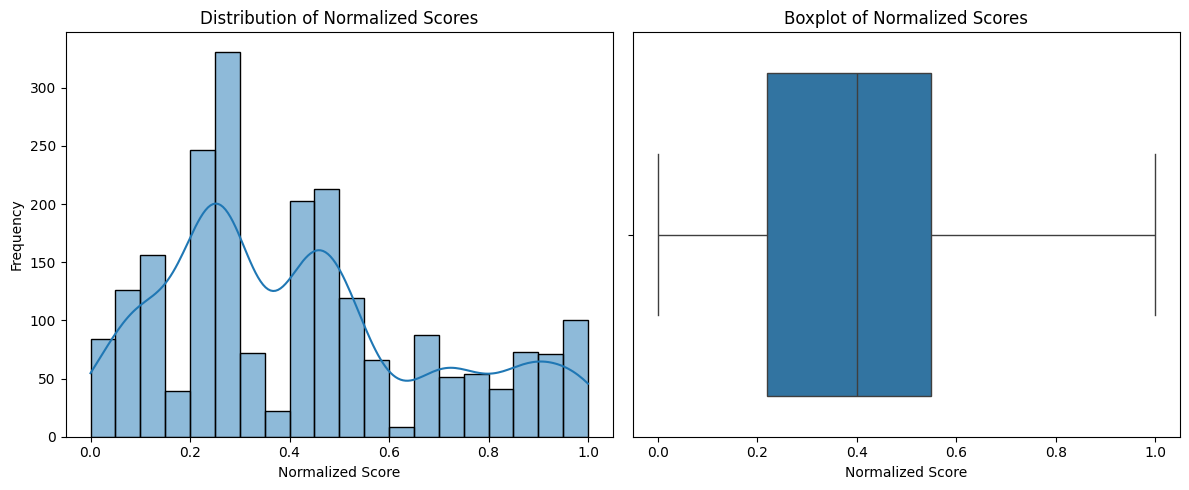

Outliers detected:
 Empty DataFrame
Columns: [reference_answer, answer, score, dataset, normalized_score, z_score]
Index: []


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Membuat subplot dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribusi skor (Histogram)
sns.histplot(df_rahumoto['normalized_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Normalized Scores")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Frequency")

# Boxplot untuk deteksi outlier
sns.boxplot(x=df_rahumoto['normalized_score'], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Scores")
axes[1].set_xlabel("Normalized Score")

# Tampilkan plot
plt.tight_layout()
plt.show()

# Hitung Z-score
zscore_value = zscore(df_rahumoto['normalized_score'])
outliers = df_rahumoto[zscore_value.abs() > 3]  # Outlier jika Z-score lebih dari 3
print("Outliers detected:\n", outliers)


In [89]:
from transformers import AutoTokenizer
# tokenizer = AutoTokenizer.from_pretrained("distilbert/distilroberta-base")
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def get_token_length(text):
    encoding = tokenizer.encode_plus(text, padding=False, truncation=False, return_tensors='pt')
    return encoding['input_ids'].flatten().shape[0]

df_rahumoto = df_rahumoto.copy()
df_rahumoto.loc[:, 'ref_len'] = df_rahumoto['reference_answer'].apply(get_token_length)
df_rahumoto.loc[:, 'stu_len'] = df_rahumoto['answer'].apply(get_token_length)
df_rahumoto[['ref_len', 'stu_len']].describe()

,ref_len,stu_len
count,2162.000000,2162.000000
mean,57.450509,34.981036
std,36.391536,45.050469
min,17.000000,3.000000
25%,37.000000,15.000000
50%,46.000000,24.000000
75%,64.000000,39.000000
max,178.000000,824.000000


In [ ]:
model = SentenceTransformer("sentence-transformers/all-distilroberta-v1")
scores = df_rahumoto.apply(
            lambda x: compute_scores(model, x["reference_answer"], x["answer"]), axis=1
        )
df_rahumoto["cos_sim"], df_rahumoto["manhattan_dist"], df_rahumoto["euclidean_dist"] = zip(*scores)

,reference_answer,answer,score,dataset,normalized_score,ref_len,stu_len,cos_sim,manhattan_dist,euclidean_dist
0,Fungsi karbohidrat adalah sebagai pemasok ener...,"sumber tenaga, pemanis alami, menjaga sistem i...",27.0,analisis_essay,0.27,32,16,0.559821,20.217268,0.938274
1,Fungsi karbohidrat adalah sebagai pemasok ener...,"sebagai sumber energi, pemanis alami, menjaga ...",21.0,analisis_essay,0.21,32,17,0.601659,19.344790,0.892571
2,Fungsi karbohidrat adalah sebagai pemasok ener...,1. Sebagai energi. 2. Sebagai memperlancaar pe...,42.0,analisis_essay,0.42,32,27,0.528983,21.194702,0.970584
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"untuk membuat kenyang, agar tidak lapar, agar ...",18.0,analisis_essay,0.18,32,18,0.628129,18.514687,0.862404
4,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat mempunyai peran penting untuk pros...,82.0,analisis_essay,0.82,32,56,0.733065,16.011646,0.730665


## asap Dataset

In [ ]:
df_asap = df[df['dataset'] == 'asap']
print(df_asap.info())
df_asap.head()

<class 'pandas.core.frame.DataFrame'>
Index: 17043 entries, 2162 to 19204
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  17043 non-null  object 
 1   answer            17043 non-null  object 
 2   score             17043 non-null  float64
 3   dataset           17043 non-null  object 
 4   normalized_score  17043 non-null  float64
dtypes: float64(2), object(3)
memory usage: 798.9+ KB
None


,reference_answer,answer,score,dataset,normalized_score
2162,You would need many more pieces of information...,Some additional information that we would need...,1.0,asap,0.333333
2163,You would need many more pieces of information...,"After reading the expirement, I realized that ...",1.0,asap,0.333333
2164,You would need many more pieces of information...,"What you need is more trials, a control set up...",1.0,asap,0.333333
2165,You would need many more pieces of information...,The student should list what rock is better an...,0.0,asap,0.000000
2166,You would need many more pieces of information...,For the students to be able to make a replicat...,2.0,asap,0.666667


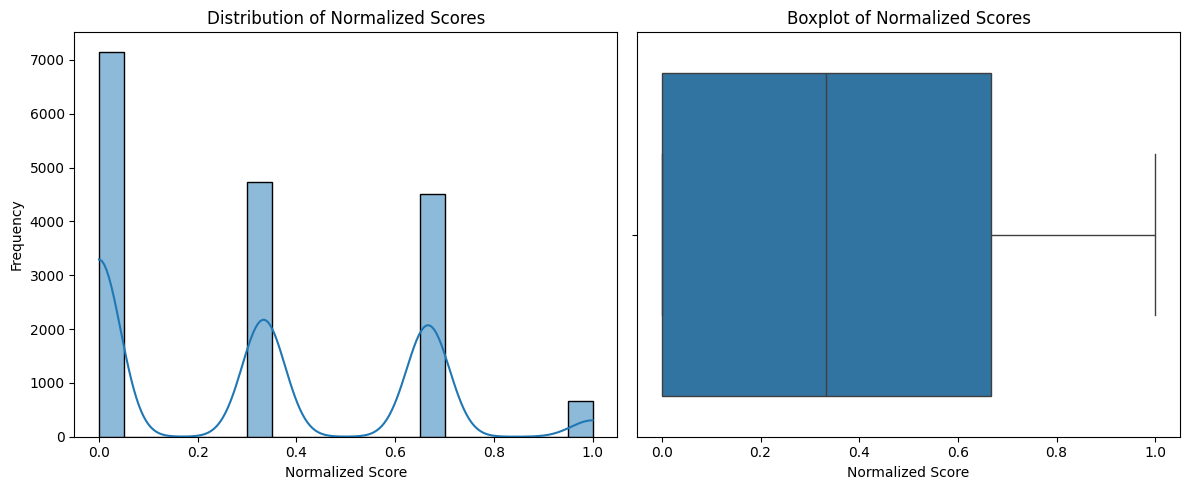

Outliers detected:
 Empty DataFrame
Columns: [reference_answer, answer, score, dataset, normalized_score]
Index: []


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Membuat subplot dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribusi skor (Histogram)
sns.histplot(df_asap['normalized_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Normalized Scores")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Frequency")

# Boxplot untuk deteksi outlier
sns.boxplot(x=df_asap['normalized_score'], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Scores")
axes[1].set_xlabel("Normalized Score")

# Tampilkan plot
plt.tight_layout()
plt.show()

# Hitung Z-score
zscore_value = zscore(df_asap['normalized_score'])
outliers = df_asap[zscore_value.abs() > 3]  # Outlier jika Z-score lebih dari 3
print("Outliers detected:\n", outliers)

## SAG Dataset

In [28]:
df_sag = df[df['dataset'] == 'sag']
print(df_sag.info())
df_sag.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2558 entries, 19376 to 21933
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  2558 non-null   object 
 1   answer            2558 non-null   object 
 2   score             2558 non-null   float64
 3   dataset           2558 non-null   object 
 4   normalized_score  2558 non-null   float64
dtypes: float64(2), object(3)
memory usage: 119.9+ KB
None


,reference_answer,answer,score,dataset,normalized_score
19376,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.5,sag,0.7
19377,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,sag,1.0
19378,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,4.0,sag,0.8
19379,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0,sag,1.0
19380,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0,sag,0.6


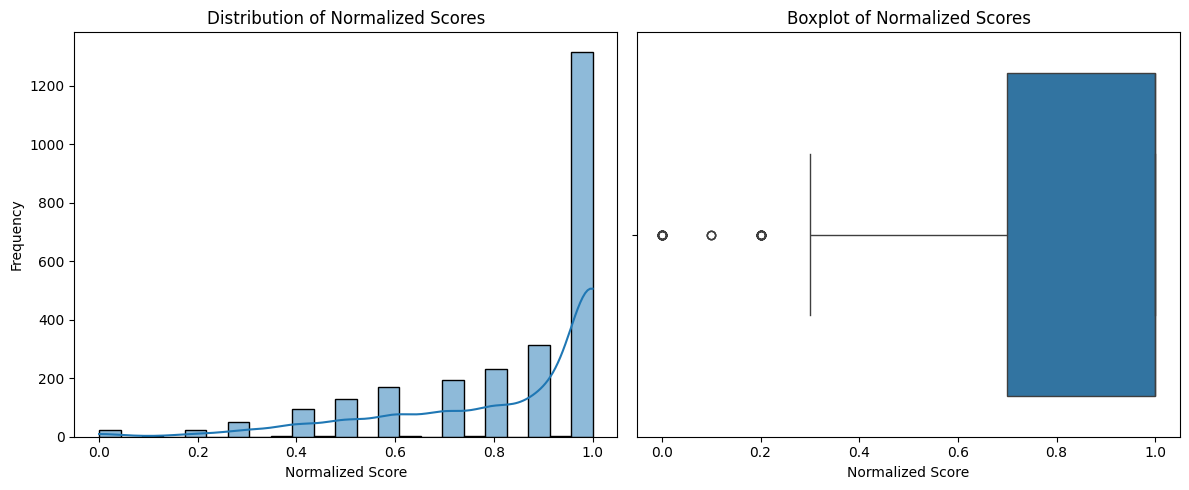

Outliers detected:



,reference_answer,answer,score,dataset,normalized_score
19470,At the main function.,in the testing phase,0.0,sag,0.0
19575,The block inside a do ... while statement will...,NO ANSWER,0.0,sag,0.0
19699,Unlimited number.,Just one per class.,0.0,sag,0.0
19704,Unlimited number.,1,0.0,sag,0.0
19706,Unlimited number.,One,0.0,sag,0.0
19719,Unlimited number.,One,0.0,sag,0.0
19720,Unlimited number.,one,0.0,sag,0.0
19723,Unlimited number.,one,0.0,sag,0.0
19726,Unlimited number.,one,0.0,sag,0.0
19762,"To store a class interface, including data mem...",No,0.0,sag,0.0


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Membuat subplot dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribusi skor (Histogram)
sns.histplot(df_sag['normalized_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Normalized Scores")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Frequency")

# Boxplot untuk deteksi outlier
sns.boxplot(x=df_sag['normalized_score'], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Scores")
axes[1].set_xlabel("Normalized Score")

# Tampilkan plot
plt.tight_layout()
plt.show()

# Hitung Z-score
zscore_value = zscore(df_sag['normalized_score'])
print("Outliers detected:\n")
outliers = df_sag[zscore_value.abs() > 3]  # Outlier jika Z-score lebih dari 3
outliers

## CUNLP

In [32]:
df_cunlp = df[df['dataset'] == 'cunlp']
print(df_cunlp.info())
df_cunlp.head()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 19205 to 19375
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  171 non-null    object 
 1   answer            171 non-null    object 
 2   score             171 non-null    float64
 3   dataset           171 non-null    object 
 4   normalized_score  171 non-null    float64
dtypes: float64(2), object(3)
memory usage: 8.0+ KB
None


,reference_answer,answer,score,dataset,normalized_score
19205,"If the question is IR-Based, I will do the fol...",Using semantic analysis methods. We can use ve...,25.0,cunlp,0.25
19206,"If the question is IR-Based, I will do the fol...","we should use vector space model. firstly, bin...",25.0,cunlp,0.25
19207,"If the question is IR-Based, I will do the fol...","Assume we have a question like "" Why the sky i...",50.0,cunlp,0.50
19208,"If the question is IR-Based, I will do the fol...",We can use Vector Space Model that is represen...,25.0,cunlp,0.25
19209,"If the question is IR-Based, I will do the fol...",In this corpus we will use sentence segmenting...,50.0,cunlp,0.50


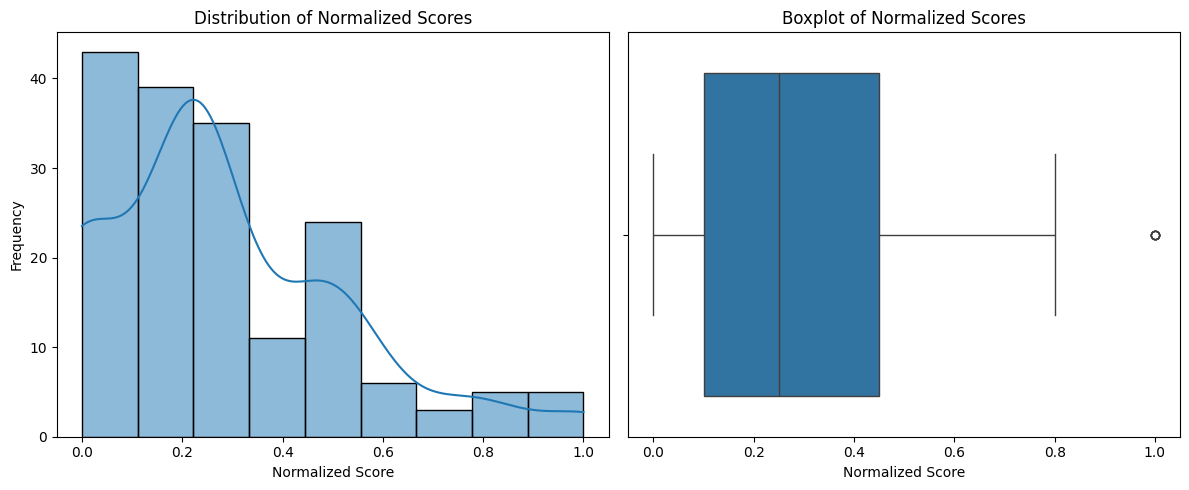

Outliers detected:



,reference_answer,answer,score,dataset,normalized_score


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Membuat subplot dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribusi skor (Histogram)
sns.histplot(df_cunlp['normalized_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Normalized Scores")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Frequency")

# Boxplot untuk deteksi outlier
sns.boxplot(x=df_cunlp['normalized_score'], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Scores")
axes[1].set_xlabel("Normalized Score")

# Tampilkan plot
plt.tight_layout()
plt.show()

# Hitung Z-score
zscore_value = zscore(df_cunlp['normalized_score'])
print("Outliers detected:\n")
outliers = df_cunlp[zscore_value.abs() > 3]  # Outlier jika Z-score lebih dari 3
outliers

## STITA Dataset

In [33]:
df_stita = df[df['dataset'] == 'stita']
print(df_stita.info())
df_stita.head()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 22073 to 22405
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  333 non-null    object 
 1   answer            333 non-null    object 
 2   score             333 non-null    float64
 3   dataset           333 non-null    object 
 4   normalized_score  333 non-null    float64
dtypes: float64(2), object(3)
memory usage: 15.6+ KB
None


,reference_answer,answer,score,dataset,normalized_score
22073,When we talk about characters we refer to all ...,When we talk about characters we refer to all ...,100.0,stita,1.00
22074,When we talk about characters we refer to all ...,Characters can be qualitative or quantitative....,59.0,stita,0.59
22075,When we talk about characters we refer to all ...,The characters in the statistical units may be...,70.0,stita,0.70
22076,When we talk about characters we refer to all ...,The types of characters are distinguished in q...,70.0,stita,0.70
22077,When we talk about characters we refer to all ...,the types of characters are. Qualitative and q...,59.0,stita,0.59


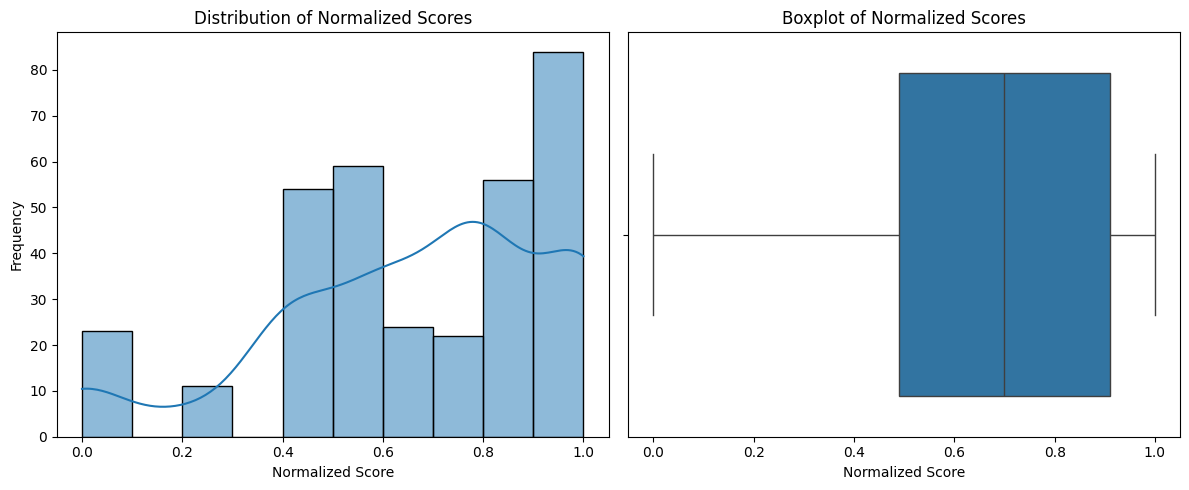

Outliers detected:



,reference_answer,answer,score,dataset,normalized_score


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Membuat subplot dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribusi skor (Histogram)
sns.histplot(df_stita['normalized_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Normalized Scores")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Frequency")

# Boxplot untuk deteksi outlier
sns.boxplot(x=df_stita['normalized_score'], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Scores")
axes[1].set_xlabel("Normalized Score")

# Tampilkan plot
plt.tight_layout()
plt.show()

# Hitung Z-score
zscore_value = zscore(df_stita['normalized_score'])
print("Outliers detected:\n")
outliers = df_stita[zscore_value.abs() > 3]  # Outlier jika Z-score lebih dari 3
outliers

## SCIENT Dataset

In [34]:
df_scient = df[df['dataset'] == 'sci']
print(df_scient.info())
df_scient.head()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 21934 to 22072
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  139 non-null    object 
 1   answer            139 non-null    object 
 2   score             139 non-null    float64
 3   dataset           139 non-null    object 
 4   normalized_score  139 non-null    float64
dtypes: float64(2), object(3)
memory usage: 6.5+ KB
None


,reference_answer,answer,score,dataset,normalized_score
21934,Like poles repel and opposite poles attract.,Because they are repelling each other always.,0.0,sci,0.0
21935,Like poles repel and opposite poles attract.,The magnets are not touching because they cann...,4.0,sci,0.8
21936,Like poles repel and opposite poles attract.,The magnets will maybe not stick because the f...,0.0,sci,0.0
21937,Like poles repel and opposite poles attract.,They are repelling.,0.0,sci,0.0
21938,Like poles repel and opposite poles attract.,The magnets are on the side when they repel ea...,0.0,sci,0.0


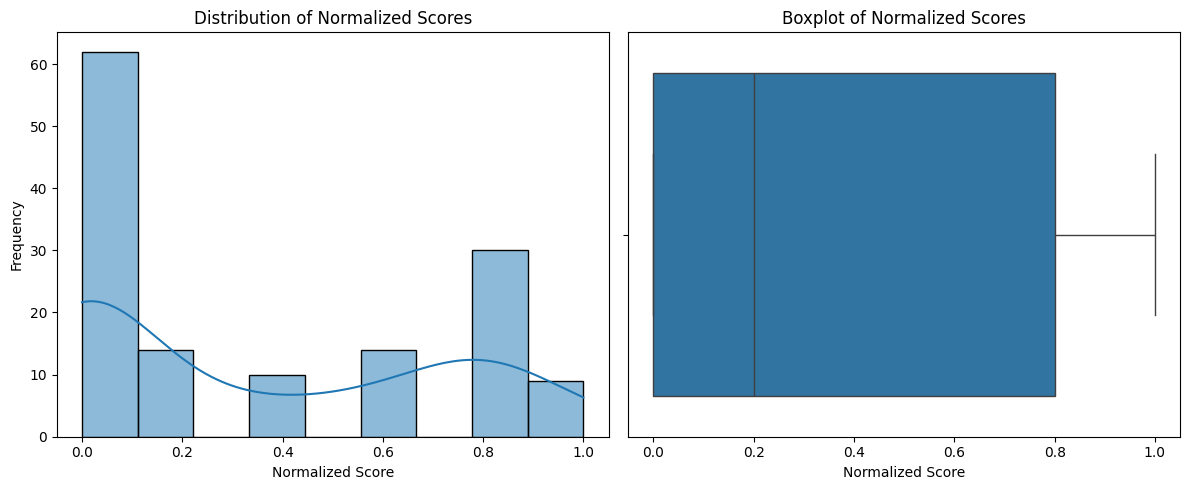

Outliers detected:



,reference_answer,answer,score,dataset,normalized_score


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Membuat subplot dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribusi skor (Histogram)
sns.histplot(df_scient['normalized_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Normalized Scores")
axes[0].set_xlabel("Normalized Score")
axes[0].set_ylabel("Frequency")

# Boxplot untuk deteksi outlier
sns.boxplot(x=df_scient['normalized_score'], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Scores")
axes[1].set_xlabel("Normalized Score")

# Tampilkan plot
plt.tight_layout()
plt.show()

# Hitung Z-score
zscore_value = zscore(df_scient['normalized_score'])
print("Outliers detected:\n")
outliers = df_scient[zscore_value.abs() > 3]  # Outlier jika Z-score lebih dari 3
outliers